# Exploration of influence of cycling on ASHP performance
This builds some simple decision trees to see whether the cycling features can help diagnose causes for under performance. The models built here are not intended for actual deployment, but to aid understanding of performance in the EoH trial.

The core finding is that a simple method of detecting cycles does a reasonable job of helping group heat pumps into intuitive categories (e.g. long cycles, low flow temperatures) that go some way to separating out causes of poor performance. Unsurprisingly, the best performing heat pumps have long cycles at low flow temperatures with only short gaps between them.

I think a good next step would be to explicitly build (probably rule-based) features designed to detect:
- low flow temperatures but cycles are shortened because the heat pump can't operate at low enough power (oversized heat pump or min flow temperature needs raising)
- seperating out "high constant flow temp" from "ramping up flow temp" and using those to recommend an action when cycles are short and gaps are long (though do they have the same action - adjust weather compensation curve?)
- identifying high flow temp, long-ish cycle, short gap heat pumps, as these probably can't just tweak the flow temp

In [224]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
import plotly.express as px
import graphviz

# Input data is all ASHPs that were included in the original EoH analysis, with cycling features calculated
homes_with_features = pd.read_csv("homes_with_features.csv")

# There are a few null values in the installation data - fill these with 0s
homes_with_features.fillna(0, inplace=True)

homes_with_features.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'median_heat_temp_diff', 'mean_power',
       'mean_modulation_pct', 'median_cycles_per_day',
       'median_internal_temp_winter', 'tenth_pct_internal_temp_winter',
       'percentage_time_on', 'annual_hot_water_demand',
       'annual_heating_demand', 'power_weighted_flow_temperature',
       'max_flow_temp', 'flow_temp_99th_pct'],
      dtype='object')

In [225]:
# Create general features
homes_with_features["actual_DHW_vs_design_DHW"] = homes_with_features['annual_hot_water_demand'] / homes_with_features['MCS_DHWAnnual']
homes_with_features["actual_annual_SH_vs_design_SH"] = homes_with_features['annual_heating_demand'] / homes_with_features['MCS_SHAnnual']
homes_with_features["HP_Size_vs_SHLoad"] = homes_with_features['HP_Size_kW'] / homes_with_features['MCS_SHLoad']
homes_with_features["HP_Size-SHLoad"] = homes_with_features['HP_Size_kW'] - homes_with_features['MCS_SHLoad']
homes_with_features["DHW%"] = homes_with_features['annual_hot_water_demand'] / (homes_with_features['annual_hot_water_demand'] + homes_with_features['annual_heating_demand'])
homes_with_features["on_to_off_duration_ratio"] = homes_with_features['median_on_duration'] / homes_with_features['median_off_duration']
homes_with_features["internal_temp_range"] = homes_with_features["median_internal_temp_winter"] - homes_with_features["tenth_pct_internal_temp_winter"]


In [226]:
fig = px.scatter(homes_with_features, x="median_off_duration", y="median_flow_temp", color="HP_Brand", 
                 title="Lots of Daikins had extremely short gaps between cycles", width=600,
                 labels={
                     "median_off_duration": "Median gap between cycles (m)",
                     "median_flow_temp": "Median flow temperature (C)",
                 },)
fig.show()

In [227]:
fig = px.scatter(homes_with_features, x="median_on_duration", y="median_flow_temp", color="HP_Brand", 
                 title="Lots of Daikins had short cycles", width=600,
                 labels={
                     "median_on_duration": "Median cycle length (min)",
                     "median_flow_temp": "Median flow temperature (C)",
                 })
fig.show()

In [230]:
# Flag specific groups
homes_with_features["Daikin_control_issue"] = (homes_with_features["HP_Brand"] == "Daikin") & (homes_with_features["median_off_duration"] <= 6)
homes_with_features["high_flow_temp"] = (homes_with_features["median_flow_temp"] >= 40)
homes_with_features["low_modulation"] = (homes_with_features["mean_modulation_pct"] < 30)
homes_with_features["high_modulation"] = (homes_with_features["mean_modulation_pct"] >= 50)
homes_with_features["lower_than_expected_SH"] = (homes_with_features["actual_annual_SH_vs_design_SH"] < 0.33)
homes_with_features["high_dhw_usage"] = (homes_with_features["DHW%"] > 0.3)
homes_with_features["high_internal_temp_range"] = (homes_with_features["internal_temp_range"] > 2)
homes_with_features["install kW lt design kW"] = (homes_with_features["HP_Size-SHLoad"] < -1)
homes_with_features["install kW gt design kW"] = (homes_with_features["HP_Size-SHLoad"] > 1)
homes_with_features["short on cycles"] = (homes_with_features["median_on_duration"] <= 40)
homes_with_features["short on, short off"] = (homes_with_features["median_on_duration"] <= 30) & (homes_with_features["median_off_duration"] <= 20)
homes_with_features["high flow temp slope"] = (homes_with_features["median_temp_change"] > 10)
homes_with_features["on <30%"] = (homes_with_features["percentage_time_on"] < 30)

# Low flow temperature but shorter cycles because heat pump can't operate at low enough power (oversized heat pum or min flow temp needs raising)
# High flow temp, long cycle, short gap heat pumps = undersized?

In [231]:
#homes_with_features = homes_with_features[~homes_with_features["Daikin_control_issue"]]


In [232]:
# Oversizing indicators
homes_with_features["Oversized: low flow temp but short cycles"] = (homes_with_features["median_flow_temp"] < 40) & (homes_with_features["median_on_duration"] <= 20)
homes_with_features["Oversized: low modulation %"] = (homes_with_features["mean_modulation_pct"] < 30)
homes_with_features["Oversized: install kW > design + 1"] = (homes_with_features["HP_Size-SHLoad"] >= 1)
homes_with_features["Oversized: actual heating demand << design"] = (homes_with_features["actual_annual_SH_vs_design_SH"] <= 0.4)
homes_with_features["# Oversizing Indicators"] = homes_with_features[homes_with_features.columns[homes_with_features.columns.str.contains("Oversized")].to_list()].sum(axis=1)

In [233]:
homes_with_features.groupby("# Oversizing Indicators")["SPFH4_selected_window"].agg(["median", "count"])

,median,count
# Oversizing Indicators,,
0,2.8335,86
1,2.8580,187
2,2.7230,115
3,2.5955,36
4,2.7540,4


In [234]:
# Undersizing indicators
homes_with_features["Undersized: install kW < design"] = (homes_with_features["HP_Size-SHLoad"] < 0)
homes_with_features["Undersized: high modulation %"] = (homes_with_features["mean_modulation_pct"] > 50)
homes_with_features["Undersized: high flow temp with long cycles"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_on_duration"] > 20)
homes_with_features["# Undersizing Indicators"] = homes_with_features[homes_with_features.columns[homes_with_features.columns.str.contains("Undersized")].to_list()].sum(axis=1)

In [235]:
homes_with_features.groupby(['Undersized: high flow temp with long cycles', "Undersized: high modulation %", "Undersized: install kW < design"])["SPFH4_selected_window"].agg(["median", "count"])

median  \
Undersized: high flow temp with long cycles Undersized: high modulation % Undersized: install kW < design           
False                                       False                         False                             2.848   
                                                                          True                              2.838   
                                            True                          False                             2.793   
                                                                          True                              2.656   
True                                        False                         False                             2.837   
                                                                          True                              2.789   
                                            True                          False                             2.693   
                                                                          True                              2.721   

                                                                                                           count  
Undersized: high flow temp with long cycles Undersized: high modulation % Undersized: install kW < design         
False                                       False                         False                              189  
                                                                          True                                 7  
                                            True                          False                               84  
                                                                          True                                11  
True                                        False                         False                               17  
                                                                          True                                 5  
                                            True                          False                              102  
                                                                          True                                13

In [236]:
homes_with_features.groupby('# Undersizing Indicators')["SPFH4_selected_window"].agg(["median", "count"])

,median,count
# Undersizing Indicators,,
0,2.8480,189
1,2.8040,108
2,2.6875,118
3,2.7210,13


In [237]:
# Weather compensation curve too high indicators
homes_with_features["High Weather Comp: high flow temp, spikey"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_temp_change"] >= 10)
homes_with_features["High Weather Comp: high flow temp, short cycles"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_on_duration"] <= 30)
homes_with_features["High Weather Comp: high flow temp, high modulation"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["mean_modulation_pct"] > 50)
#homes_with_features["# High Weather Comp Indicators"] = homes_with_features[homes_with_features.columns[homes_with_features.columns.str.contains("High Weather Comp")].to_list()].sum(axis=1)

In [238]:
homes_with_features.groupby(homes_with_features.columns[homes_with_features.columns.str.contains("High Weather Comp")].to_list())["SPFH4_selected_window"].agg(["median", "count"])

median  \
High Weather Comp: high flow temp, spikey High Weather Comp: high flow temp, short cycles High Weather Comp: high flow temp, high modulation           
False                                     False                                           False                                               2.8510   
                                                                                          True                                                2.5435   
                                          True                                            False                                               2.5725   
                                                                                          True                                                2.5410   
True                                      False                                           False                                               2.6795   
                                                                                          True                                                2.7560   
                                          True                                            True                                                2.5700   

                                                                                                                                              count  
High Weather Comp: high flow temp, spikey High Weather Comp: high flow temp, short cycles High Weather Comp: high flow temp, high modulation         
False                                     False                                           False                                                 264  
                                                                                          True                                                   14  
                                          True                                            False                                                  26  
                                                                                          True                                                   34  
True                                      False                                           False                                                   2  
                                                                                          True                                                   69  
                                          True                                            True                                                   19

In [239]:
# Low flow temperatures but low space heating demand (modelled or otherwise)
homes_with_features["Low flow temp but low demand"] = (homes_with_features["median_flow_temp"] < 40) & (homes_with_features["MCS_SHAnnual"] < 12000)

In [240]:
homes_with_features.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'median_heat_temp_diff', 'mean_power',
       'mean_modulation_pct', 'median_cycles_per_day',
       'median_internal_temp_winter', 'tenth_pct_internal_temp_winter',
       'percentage_time_on', 'annual_hot_water_demand',
       'annual_heating_demand', 'power_weighted_flow_temperature',
       'max_flow_temp', 'flow_temp_99th_pct', 'actual_DHW_vs_design_DHW',
       'actual_annual_SH_vs_des

In [241]:
px.scatter(homes_with_features[homes_with_features["MCS_Flow_Temp"] > 0], x="MCS_Flow_Temp", y="SPFH4_selected_window", title = "SPFH4 vs MCS Design Flow Flow Temp",
           labels={
                     "MCS_Flow_Temp": "MCS Design Flow Temperature (C)",
                     "SPFH4_selected_window": "SPFH4",
                 }, trendline="ols", width=700, range_x=[30,70])

In [242]:
px.scatter(homes_with_features, x="flow_temp_99th_pct", y="SPFH4_selected_window", title = "SPFH4 vs Maximum Heating Flow Temp",
           labels={
                     "flow_temp_99th_pct": "99th Percentile Heating Flow Temperature (C)",
                     "SPFH4_selected_window": "SPFH4",
                 }, trendline="ols", width=700, range_x=[30,70])

In [243]:
px.scatter(homes_with_features, x="median_flow_temp", y="SPFH4_selected_window", title = "SPFH4 vs Median Heating Flow Temp",
                labels={
                "median_flow_temp": "Median Heating Flow Temperature (C)",
                "SPFH4_selected_window": "SPFH4",
            }, trendline="ols", width=700)

In [244]:
px.scatter(homes_with_features, x="power_weighted_flow_temperature", y="SPFH4_selected_window", title = "SPFH4 vs Power-weighted Heating Flow Temp",
                labels={
                "power_weighted_flow_temperature": "Typical Heating Flow Temperature, weighted by power output (C)",
                "SPFH4_selected_window": "SPFH4",
            }, trendline="ols", width=700, range_x=[30,70])

In [245]:
# Weather compensation curves set too high
# - high flow temperatures with strong ramps and low percentage on
homes_with_features["Poor heating schedule"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["internal_temp_range"] > 2) & (homes_with_features["median_off_duration"] >= 120)
homes_with_features["Weather Compensation too high"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_temp_change"] > 10)
homes_with_features["Min flow temp too low"] = (homes_with_features["mean_modulation_pct"] < 30)


#homes_with_features = homes_with_features[~homes_with_features["Daikin_control_issue"]]

# Low flow temperature but shorter cycles because heat pump can't operate at low enough power (oversized heat pum or min flow temp needs raising)
# High flow temp, long cycle, short gap heat pumps = undersized?

In [246]:
homes_with_features[homes_with_features["Weather Compensation too high"]]

,Property_ID,HP_Installed,HP_Brand,HP_Model,HP_Size_kW,HP_Refrigerant,SPFH4_selected_window,HP_Energy_Output_selected_window,Mean_annual_SH_flow_temp_selected_window,Mean_annual_HW_flow_temp_selected_window,...,Undersized: high modulation %,Undersized: high flow temp with long cycles,# Undersizing Indicators,"High Weather Comp: high flow temp, spikey","High Weather Comp: high flow temp, short cycles","High Weather Comp: high flow temp, high modulation",Low flow temp but low demand,Poor heating schedule,Weather Compensation too high,Min flow temp too low
4,EOH0031,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,2.901,17540.01,40.46,42.58,...,True,True,2,True,True,True,False,False,True,False
7,EOH0047,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,3.011,21341.22,34.92,34.91,...,True,True,2,True,False,True,False,False,True,False
8,EOH0048,ASHP,Mitsubishi,PUZ-WM85VAA,8.5,R32,2.904,12820.70,41.93,44.50,...,True,True,2,True,False,True,False,False,True,False
14,EOH0082,ASHP,Mitsubishi,PUZ-WM85VAA,8.5,R32,3.221,14153.70,42.34,43.61,...,True,True,2,True,False,True,False,False,True,False
34,EOH0227,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,2.707,15886.77,45.48,47.01,...,True,True,2,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,EOH3107,ASHP,Mitsubishi,PUHZ-W85VHAA,8.5,R410A,3.046,21090.83,44.97,45.33,...,True,True,2,True,False,True,False,False,True,False
417,EOH3128,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,2.721,10065.81,48.60,49.17,...,True,True,3,True,False,True,False,False,True,False
419,EOH3143,HT_ASHP,Vaillant,VWL 55/6 A 230V S2,5.0,R290,2.804,7738.65,45.75,47.21,...,True,True,2,True,False,True,False,False,True,False
420,EOH3151,ASHP,Mitsubishi,PUHZ-W50VHA2,5.0,R410A,2.805,8575.95,42.98,45.85,...,True,True,2,True,False,True,False,False,True,False


In [247]:
homes_with_features[homes_with_features["Poor heating schedule"]]

,Property_ID,HP_Installed,HP_Brand,HP_Model,HP_Size_kW,HP_Refrigerant,SPFH4_selected_window,HP_Energy_Output_selected_window,Mean_annual_SH_flow_temp_selected_window,Mean_annual_HW_flow_temp_selected_window,...,Undersized: high modulation %,Undersized: high flow temp with long cycles,# Undersizing Indicators,"High Weather Comp: high flow temp, spikey","High Weather Comp: high flow temp, short cycles","High Weather Comp: high flow temp, high modulation",Low flow temp but low demand,Poor heating schedule,Weather Compensation too high,Min flow temp too low
219,EOH1686,HT_ASHP,Vaillant,VWL 105/6 A 230V S2,10.0,R290,2.629,6246.62,52.3,52.69,...,True,True,2,True,False,True,False,True,True,False


In [248]:
homes_with_features

,Property_ID,HP_Installed,HP_Brand,HP_Model,HP_Size_kW,HP_Refrigerant,SPFH4_selected_window,HP_Energy_Output_selected_window,Mean_annual_SH_flow_temp_selected_window,Mean_annual_HW_flow_temp_selected_window,...,Undersized: high modulation %,Undersized: high flow temp with long cycles,# Undersizing Indicators,"High Weather Comp: high flow temp, spikey","High Weather Comp: high flow temp, short cycles","High Weather Comp: high flow temp, high modulation",Low flow temp but low demand,Poor heating schedule,Weather Compensation too high,Min flow temp too low
0,EOH0003,ASHP,Daikin,EDLQ07CAV7,7.0,R410A,2.502,8811.39,30.74,34.23,...,False,False,0,False,False,False,True,False,False,True
1,EOH0005,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,3.405,10964.88,35.60,38.82,...,False,False,0,False,False,False,False,False,False,True
2,EOH0021,ASHP,Mitsubishi,PUZ-WM85VAA-BS,8.5,R32,2.810,9248.67,33.97,36.94,...,True,False,1,False,False,False,False,False,False,False
3,EOH0026,ASHP,Daikin,EDLQ07CAV8,7.0,R410A,2.724,14116.03,37.76,38.26,...,True,False,1,False,False,False,True,False,False,False
4,EOH0031,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,2.901,17540.01,40.46,42.58,...,True,True,2,True,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,EOH3177,ASHP,Mitsubishi,PUZ-WM85VAA,8.5,R32,2.646,16774.12,47.58,49.21,...,True,False,1,False,True,True,False,False,False,False
424,EOH3186,ASHP,Mitsubishi,PUZ-HWM140VHA,14.0,R32,3.216,28611.15,42.88,44.27,...,True,True,2,True,False,True,False,False,True,False
425,EOH3188,ASHP,Daikin,EDLQ011CAV3,11.0,R410A,2.550,10290.35,32.14,33.25,...,False,False,0,False,False,False,False,False,False,False
426,EOH3196,ASHP,Mitsubishi,PUHZ-W85VHAA,8.5,R410A,3.512,11223.91,37.96,39.16,...,False,False,0,False,False,False,False,False,False,False


In [249]:
homes_with_features.groupby("Poor heating schedule")["SPFH4_selected_window"].median()

Poor heating schedule
False    2.786
True     2.629
Name: SPFH4_selected_window, dtype: float64

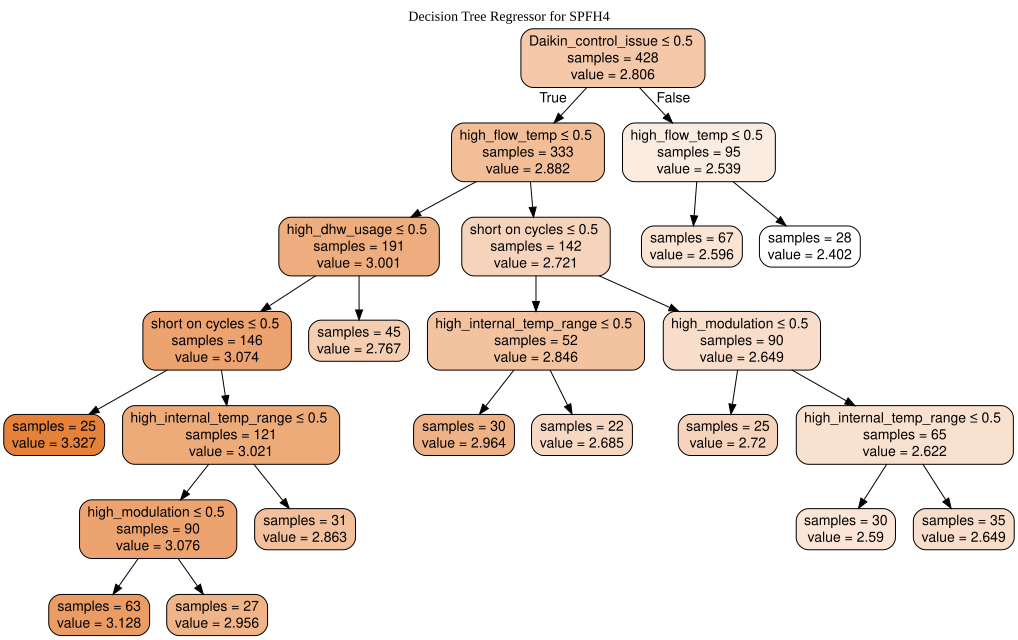

In [255]:
#homes_with_features = homes_with_features[homes_with_features["Low flow temp but low demand"]]

# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features = homes_with_features[[
                                "high_internal_temp_range",
                                #"install kW ~ design kW",
                                #"install kW lt design kW",
                                #"install kW gt design kW",
                                #"lower_than_expected_SH",
                                "low_modulation",
                                #"actual_annual_SH_vs_design_SH",
                                #'percentage_time_on',
                                #'internal_temp_range',
                                'high_dhw_usage',
                                'high_modulation',
                                'high_flow_temp',
                                'Daikin_control_issue',
                                'short on cycles',
                                #"short on, short off",
                                #"median_on_duration",
                                "high flow temp slope",
                                "on <30%",
                                "Daikin_control_issue",
                                #'DHW%',
                                ]]
categorical_cols = features.select_dtypes(include=['object', 'category']).columns
features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target = "SPFH4_selected_window"
regression_target_values = homes_with_features[regression_target]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor = DecisionTreeRegressor(random_state=4, max_depth=6, min_samples_leaf=20)
tree_regressor.fit(features, regression_target_values)

# Export the tree to Graphviz format
dot_data_reg = export_graphviz(tree_regressor, out_file=None, 
                           feature_names=features.columns,
                           impurity=False,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg = dot_data_reg.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for SPFH4";\nlabelloc="t";')

# Create and display the graph
graph_reg = graphviz.Source(dot_data_reg)
graph_reg.render("Decision Tree Regressor", format="png")
graph_reg


In [251]:
homes_with_features.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'median_heat_temp_diff', 'mean_power',
       'mean_modulation_pct', 'median_cycles_per_day',
       'median_internal_temp_winter', 'tenth_pct_internal_temp_winter',
       'percentage_time_on', 'annual_hot_water_demand',
       'annual_heating_demand', 'power_weighted_flow_temperature',
       'max_flow_temp', 'flow_temp_99th_pct', 'actual_DHW_vs_design_DHW',
       'actual_annual_SH_vs_des

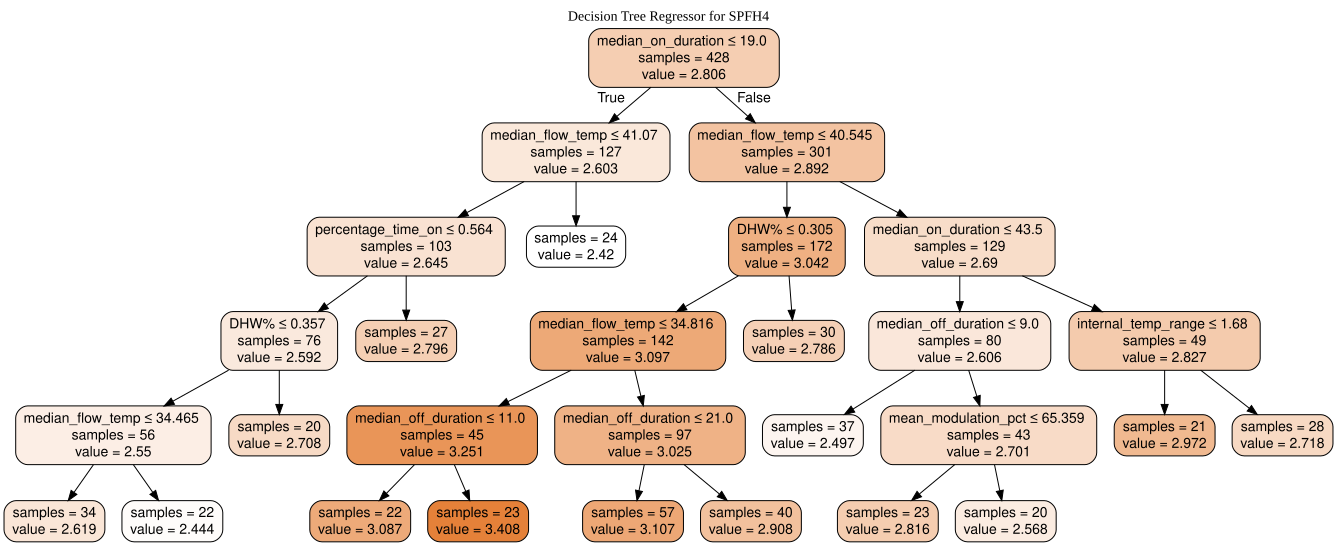

In [252]:
#homes_with_features = homes_with_features[homes_with_features["Low flow temp but low demand"]]

# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features = homes_with_features[[
                                #"install kW ~ design kW",
                                #"install kW lt design kW",
                                #"lower_than_expected_SH",
                                #"actual_annual_SH_vs_design_SH",
                                'median_heat_temp_diff', 
                                'mean_power',
                                #'annual_heating_demand',
                                'mean_modulation_pct',
                                'median_flow_temp',
                                'percentage_time_on',
                                'internal_temp_range',
                                #'Daikin_control_issue',
                                #"short on, short off",
                                "median_on_duration",
                                "median_off_duration",
                                'DHW%',
                                ]]
categorical_cols = features.select_dtypes(include=['object', 'category']).columns
features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target = "SPFH4_selected_window"
regression_target_values = homes_with_features[regression_target]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor = DecisionTreeRegressor(random_state=4, max_depth=5, min_samples_leaf=20)
tree_regressor.fit(features, regression_target_values)

# Export the tree to Graphviz format
dot_data_reg = export_graphviz(tree_regressor, out_file=None, 
                           feature_names=features.columns,
                           impurity=False,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg = dot_data_reg.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for SPFH4";\nlabelloc="t";')

# Create and display the graph
graph_reg = graphviz.Source(dot_data_reg)
graph_reg.render("Decision Tree Regressor", format="png")
graph_reg


In [132]:
groups = homes_with_features.copy()

groups["group"] = None
groups.loc[groups["Daikin_control_issue"], "group"] = "Daikin control issue"
groups.loc[~groups["Daikin_control_issue"] & 
           groups["high_flow_temp"] &
           (groups["lower_than_expected_SH"] | groups["install kW gt design kW"]), "group"] = "High flow temperature and potential oversizing"
groups.loc[~groups["Daikin_control_issue"] & 
           groups["high_flow_temp"] &
           ~(groups["lower_than_expected_SH"] | groups["install kW gt design kW"]) &
           groups["high_internal_temp_range"], "group"] = "High flow temperature and low set back temperature? (maybe weather compensation)"
groups.loc[~groups["Daikin_control_issue"] & 
           groups["high_flow_temp"] &
           ~(groups["lower_than_expected_SH"] | groups["install kW gt design kW"]) &
           ~groups["high_internal_temp_range"], "group"] = "High flow temperature, steady internal temperature (maybe weather compensation)"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           groups["high_dhw_usage"], "group"] = "Low flow temperature, but high hot water usage"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           groups["high_modulation"], "group"] = "Low flow temperature, but high modulation - potential undersizing?"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           ~groups["high_modulation"] &
           groups["high_internal_temp_range"], "group"] = "Low flow temperature, but high internal temperature variation - adjust set back temperature?"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           ~groups["high_modulation"] &
           ~groups["high_internal_temp_range"] &
           groups["high flow temp slope"], "group"] = "Low flow temperature, but high flow temperature slope - maybe weather compensation curve is too high?"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           ~groups["high_modulation"] &
           ~groups["high_internal_temp_range"] &
           ~groups["high flow temp slope"], "group"] = "No automatically identifiable issues"

In [133]:
group_stats = groups.groupby("group")[['SPFH4_selected_window', 'median_on_duration', 'percentage_time_on', 'median_flow_temp', 'power_weighted_flow_temperature', 'mean_modulation_pct', 'median_temp_change', 'median_internal_temp_winter', 'internal_temp_range', 'annual_heating_demand', 'DHW%']].mean().round(2)
group_counts = groups.groupby("group")['Property_ID'].count()
group_stats = group_stats.join(group_counts)
group_stats.rename(columns={'Property_ID': 'Count'}, inplace=True)
group_stats.to_csv("group_stats.csv")
group_stats

,SPFH4_selected_window,median_on_duration,percentage_time_on,median_flow_temp,power_weighted_flow_temperature,mean_modulation_pct,median_temp_change,median_internal_temp_winter,internal_temp_range,annual_heating_demand,DHW%,Count
group,,,,,,,,,,,,
High flow temperature and low set back temperature? (maybe weather compensation),2.67,70.83,0.44,45.39,45.47,62.67,18.02,19.93,3.09,10695.15,0.15,23
High flow temperature and potential oversizing,2.71,59.85,0.40,44.02,46.06,56.24,16.84,18.91,2.17,8981.36,0.22,78
"High flow temperature, steady internal temperature (maybe weather compensation)",2.67,58.67,0.46,45.57,46.58,60.86,18.85,19.39,1.28,9721.80,0.22,24
"Low flow temperature, but high flow temperature slope - maybe weather compensation curve is too high?",3.17,70.93,0.48,35.54,39.21,42.57,15.04,18.65,1.29,9026.46,0.18,30
"Low flow temperature, but high hot water usage",2.75,38.54,0.39,33.88,42.39,42.56,10.11,18.34,1.63,4899.37,0.40,50
"Low flow temperature, but high internal temperature variation - adjust set back temperature?",3.00,46.67,0.50,34.32,40.38,38.86,9.20,18.21,3.00,9102.78,0.19,43
"Low flow temperature, but high modulation - potential undersizing?",2.87,50.24,0.42,36.90,39.75,58.17,14.94,18.29,1.59,9045.45,0.15,25
No automatically identifiable issues,3.07,29.42,0.54,34.71,40.05,37.72,5.86,18.88,1.26,9566.43,0.20,67


In [134]:
groups[groups["group"] == "Low flow temperature, but high internal temperature variation - adjust set back temperature?"]

,Property_ID,HP_Installed,HP_Brand,HP_Model,HP_Size_kW,HP_Refrigerant,SPFH4_selected_window,HP_Energy_Output_selected_window,Mean_annual_SH_flow_temp_selected_window,Mean_annual_HW_flow_temp_selected_window,...,Undersized: high flow temp with long cycles,# Undersizing Indicators,"High Weather Comp: high flow temp, spikey","High Weather Comp: high flow temp, short cycles","High Weather Comp: high flow temp, high modulation",Low flow temp but low demand,Poor heating schedule,Weather Compensation too high,Min flow temp too low,group
2,EOH0021,ASHP,Mitsubishi,PUZ-WM85VAA-BS,8.5,R32,2.810,9248.67,33.97,36.94,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
11,EOH0066,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,3.900,6915.52,28.86,29.90,...,False,1,False,False,False,False,False,False,True,"Low flow temperature, but high internal temper..."
16,EOH0094,ASHP,Mitsubishi,PUHZ-HW140VHA2R5,14.0,R410A,3.527,18336.62,34.82,37.71,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
31,EOH0218,HT_ASHP,Vaillant,VWL 105/6 A 230V S2,10.0,R290,2.885,10069.61,35.33,40.77,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
55,EOH0346,ASHP,Mitsubishi,PUZ-WM85VAA,8.5,R32,3.206,15771.69,38.12,41.33,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
66,EOH0467,ASHP,Mitsubishi,PUHZ-W50VHA2,5.0,R410A,2.729,3841.05,37.25,38.12,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
67,EOH0470,ASHP,Mitsubishi,PUZ-WM112VAA,11.2,R32,3.557,11400.18,32.83,35.37,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
73,EOH0501,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,2.880,11675.45,44.10,46.17,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
79,EOH0534,ASHP,Mitsubishi,PUHZ-HW140VHA2R5,14.0,R410A,2.858,17076.15,36.05,39.15,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."
81,EOH0543,HT_ASHP,Vaillant,VWL 125/6 A 230V S2,12.0,R290,2.895,16344.92,40.51,46.84,...,False,0,False,False,False,False,False,False,False,"Low flow temperature, but high internal temper..."


In [559]:
groups.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'mean_power', 'mean_modulation_pct',
       'median_cycles_per_day', 'median_internal_temp_winter',
       'tenth_pct_internal_temp_winter', 'percentage_time_on',
       'annual_hot_water_demand', 'annual_heating_demand',
       'power_weighted_flow_temperature', 'actual_DHW_vs_design_DHW',
       'actual_annual_SH_vs_design_SH', 'HP_Size_vs_SHLoad', 'HP_Size-SHLoad',
       'DHW%', 'on_to_o

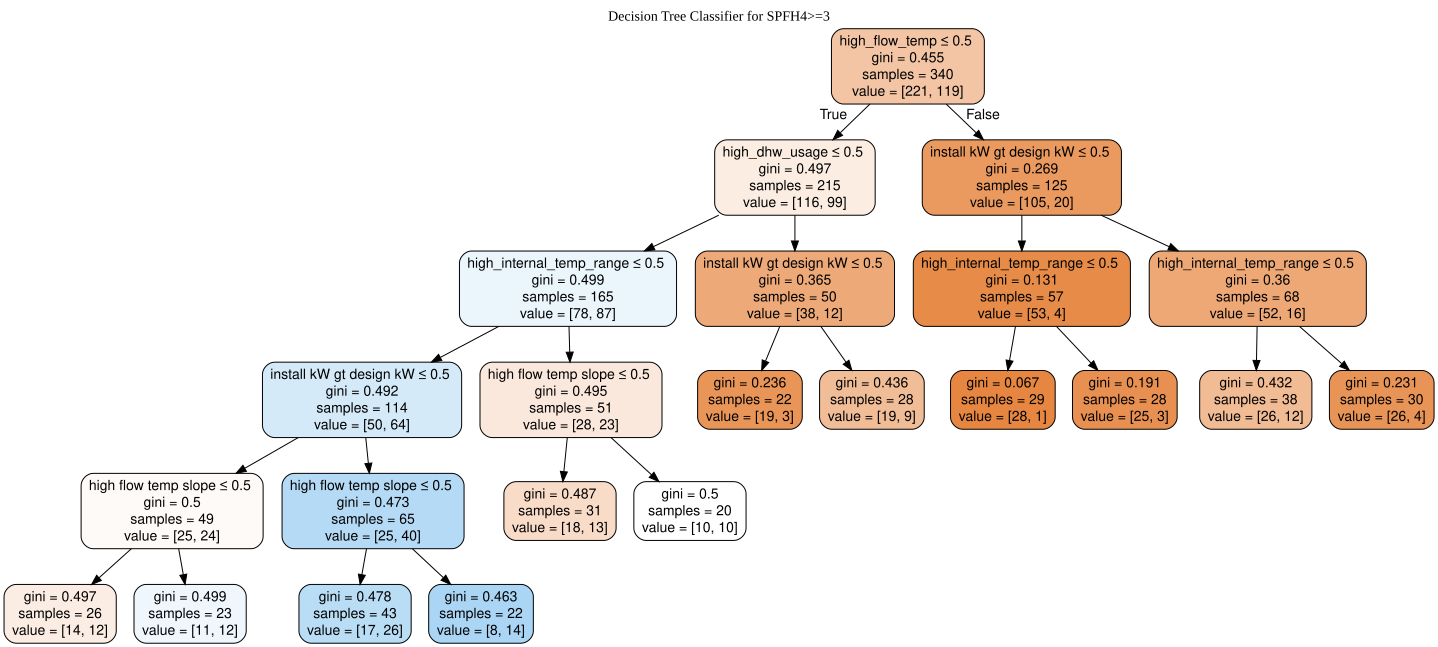

In [60]:
# Define "Good" performance as SPFH4 >= 3
homes_with_features["Good_Performance"] = homes_with_features["SPFH4_selected_window"] >= 3
target = "Good_Performance"
target_values = homes_with_features[target]

# Initializing and training the Decision Tree Classifier
tree_classifier = DecisionTreeClassifier(random_state=4, max_depth=6, min_samples_leaf=20)
tree_classifier.fit(features, target_values)

# Export the tree to Graphviz format
dot_data = export_graphviz(tree_classifier, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data = dot_data.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Classifier for SPFH4>=3";\nlabelloc="t";')
graph = graphviz.Source(dot_data)
graph.render("Decision Tree Classifier", format="png")
graph

In [65]:
homes_with_features.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'mean_power', 'mean_modulation_pct',
       'median_cycles_per_day', 'median_internal_temp_winter',
       'tenth_pct_internal_temp_winter', 'percentage_time_on',
       'annual_hot_water_demand', 'annual_heating_demand',
       'power_weighted_flow_temperature', 'max_flow_temp',
       'flow_temp_99th_pct', 'actual_DHW_vs_design_DHW',
       'actual_annual_SH_vs_design_SH', 'HP_Size_vs_SHLo

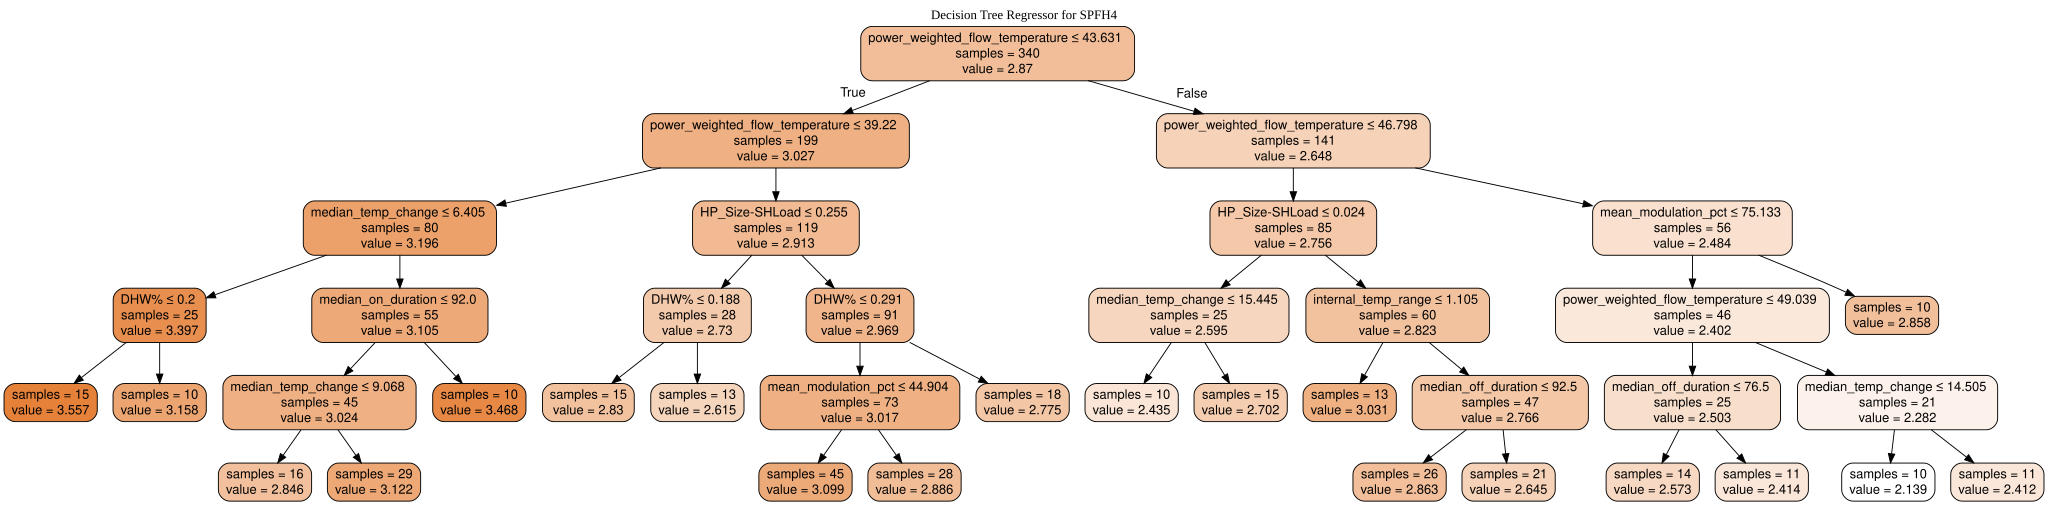

In [76]:
#homes_with_features = homes_with_features[homes_with_features["Low flow temp but low demand"]]
homes_with_features["Good_Performance"] = homes_with_features["SPFH4_selected_window"] >= 3
# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features = homes_with_features[[
    'median_on_duration',
    'median_off_duration',
    'DHW%',
    'HP_Size-SHLoad',
    'Daikin_control_issue',
    'median_temp_change',
    'mean_modulation_pct',
    'internal_temp_range',
    'power_weighted_flow_temperature',
]]                        
categorical_cols = features.select_dtypes(include=['object', 'category']).columns
features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target = "SPFH4_selected_window"
regression_target_values = homes_with_features[regression_target]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor = DecisionTreeRegressor(random_state=4, max_depth=5, min_samples_leaf=10)
tree_regressor.fit(features, regression_target_values)

# Export the tree to Graphviz format
dot_data_reg = export_graphviz(tree_regressor, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True, impurity=False, 
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg = dot_data_reg.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for SPFH4";\nlabelloc="t";')

# Create and display the graph
graph_reg = graphviz.Source(dot_data_reg)
graph_reg.render("Decision Tree Regressor", format="png")
graph_reg


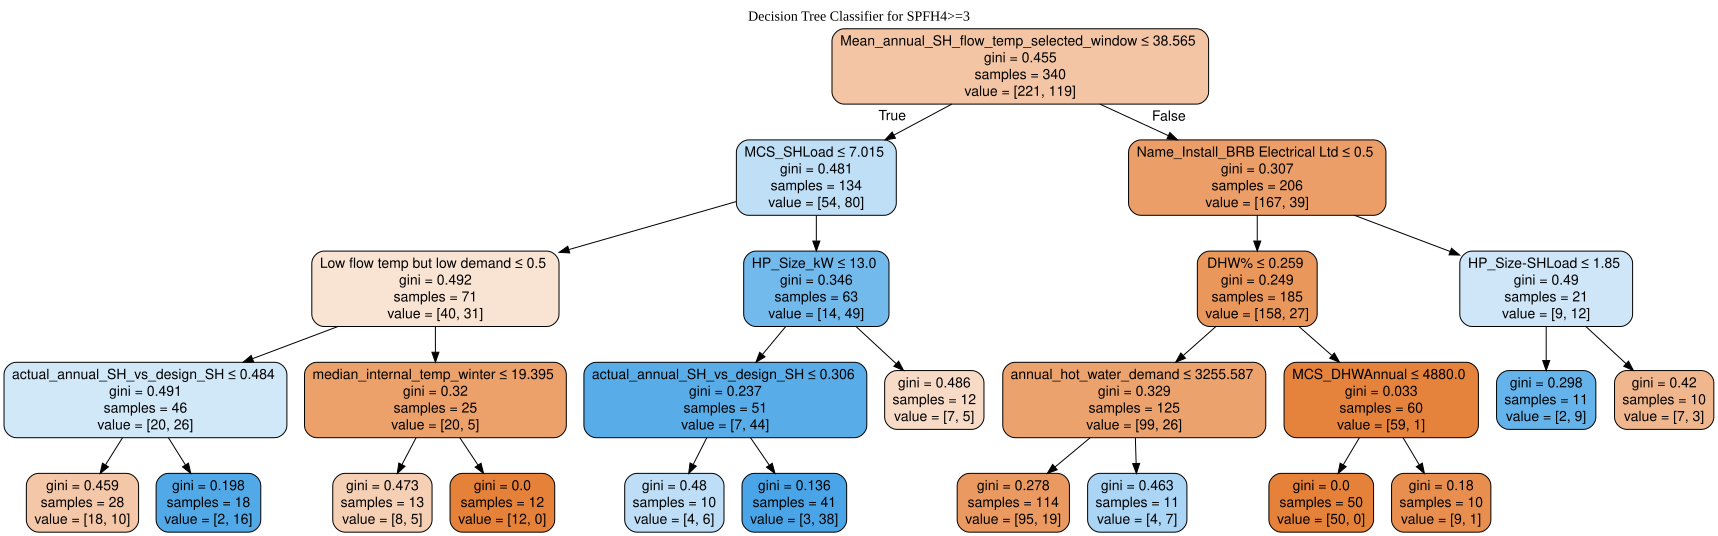

In [ ]:
# Define "Good" performance as SPFH4 >= 3
target = "Good_Performance"
target_values = homes_with_features[target]

# Initializing and training the Decision Tree Classifier
tree_classifier = DecisionTreeClassifier(random_state=4, max_depth=4, min_samples_leaf=10)
tree_classifier.fit(features, target_values)

# Export the tree to Graphviz format
dot_data = export_graphviz(tree_classifier, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data = dot_data.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Classifier for SPFH4>=3";\nlabelloc="t";')
graph = graphviz.Source(dot_data)
graph.render("Decision Tree Classifier", format="png")
graph

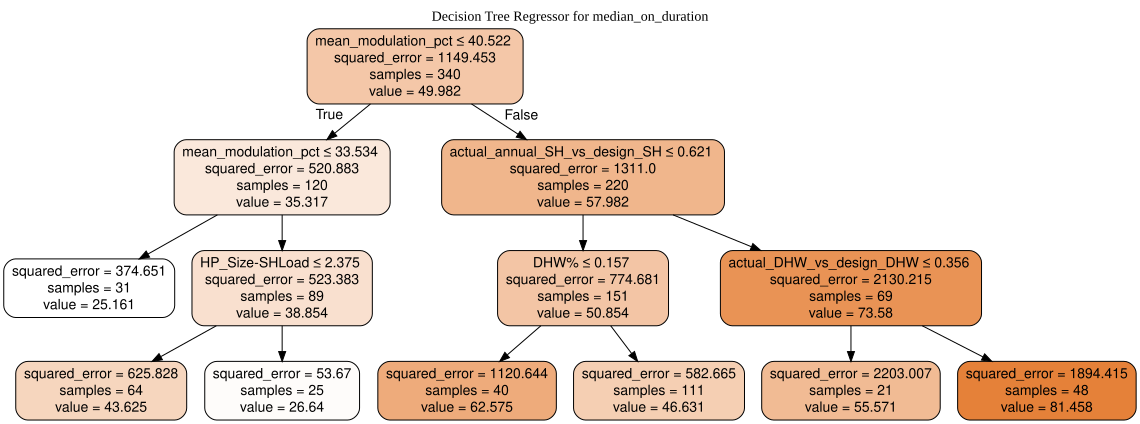

In [156]:


# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features2 = homes_with_features[[
                                #"median_on_duration",
                                #"median_off_duration",
                                #'power_weighted_flow_temperature',
                                "median_flow_temp",
                                "mean_modulation_pct",
                                #"median_cycles_per_day",
                                #'annual_hot_water_demand',
                                #'annual_heating_demand',
                                #'MCS_DHWAnnual',
                                #'HP_Size_kW',
                                #'MCS_SHAnnual',
                                #'MCS_SHLoad', 
                                #'MCS_Hloss',
                                'actual_DHW_vs_design_DHW',
                                'actual_annual_SH_vs_design_SH',
                                'HP_Size_vs_SHLoad',
                                'HP_Size-SHLoad',
                                'DHW%',
                                'high_dhw_usage',
                                'lower_than_expected_SH',
                                'high_flow_temp',
                                'Daikin_control_issue'
                                ]]
categorical_cols = features2.select_dtypes(include=['object', 'category']).columns
features2 = pd.get_dummies(features2, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target2 = "median_on_duration"
regression_target_values2 = homes_with_features[regression_target2]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor2 = DecisionTreeRegressor(random_state=4, max_depth=3, min_samples_leaf=20)
tree_regressor2.fit(features2, regression_target_values2)

# Export the tree to Graphviz format
dot_data_reg2 = export_graphviz(tree_regressor2, out_file=None, 
                           feature_names=features2.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg2 = dot_data_reg2.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for median_on_duration";\nlabelloc="t";')

# Create and display the graph
graph_reg2 = graphviz.Source(dot_data_reg2)
graph_reg2.render("Decision Tree Regressor oon duration", format="png")
graph_reg2


In [18]:
groups = homes_with_features.copy()
groups["Group"] = None


groups["Daikin_control_issue"] = (groups["HP_Brand"] == "Daikin") & (groups["median_off_duration"] <= 6)

# The better performing heat pumps - long periods at lower flow temperatures
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] < 39.3)
           & (groups["median_off_duration"] <= 15), "Group"] = "Long cycles at low temperature, short gaps"
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] < 39.3)
           & (groups["median_off_duration"] > 15), "Group"] = "Long cycles at low temperature, longer gaps"

# Shorter cycles
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] >= 36.75), "Group"] = "Short cycles at high temperature"
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] < 36.75)
           & (groups["median_hw_duration"] > 87), "Group"] = "Short cycles at low temperature with shorter hot water"
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] < 36.75)
           & (groups["median_hw_duration"] <= 87), "Group"] = "Short cycles at low temperature with longer hot water"

# Longer cycles at higher temperatures
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] >= 39.3), "Group"] = "Long cycles at higher temperatures"

In [5]:
groups.groupby("Group").agg(count=("Property_ID", "count"),
                            median_spfh4=("SPFH4_selected_window", "median"),
                            pct_with_spfh4_gt_3=("Good_Performance", "mean"))

,count,median_spfh4,pct_with_spfh4_gt_3
Group,,,
Long cycles at higher temperatures,138,2.6955,0.159420
"Long cycles at low temperature, longer gaps",153,2.9770,0.483660
"Long cycles at low temperature, short gaps",17,3.2570,0.764706
Short cycles at high temperature,30,2.4095,0.066667
Short cycles at low temperature with longer hot water,80,2.6680,0.137500
Short cycles at low temperature with shorter hot water,10,2.9345,0.400000


In [6]:
px.histogram(groups, x="median_off_duration", color="HP_Brand")

In [7]:
px.histogram(groups, x="median_on_duration", color="HP_Brand")

In [8]:
px.scatter(groups, x="median_on_duration", y="median_off_duration", color="HP_Brand", width=600)

In [9]:
fig = px.scatter(groups, x="median_on_duration", y="median_flow_temp", color="HP_Brand", width=600)
fig.show()

In [ ]:
fig = px.scatter(groups, x="median_off_duration", y="median_flow_temp", color="HP_Brand", 
                 title="Lots of Daikins had extremely short gaps between cycles", width=600,
                 labels={
                     "median_off_duration": "Median gap between cycles (m)",
                     "median_flow_temp": "Median flow temperature (C)",
                 },)
fig.show()

In [15]:
fig = px.scatter(groups, x="median_off_duration", y="median_on_duration", color="HP_Brand", title="", width=600)
fig.show()

In [97]:
fig = px.scatter(homes_with_features, x="mean_modulation_pct", y="SPFH4_selected_window", width=800, height=700)
fig.show()

In [24]:
fig = px.scatter(groups[groups["Daikin_control_issue"]], x="median_flow_temp", y="SPFH4_selected_window", width=800, height=700)
fig.show()

In [27]:
groups["flow_temp_band"] = (groups["median_flow_temp"] / 5).round() * 5

In [28]:
groups.groupby(["Daikin_control_issue", "flow_temp_band"])["SPFH4_selected_window"].describe()

count      mean       std    min  \
Daikin_control_issue flow_temp_band                                     
False                20.0              9.0  2.660556  0.299465  2.122   
                     30.0             36.0  3.100611  0.553731  1.848   
                     35.0            118.0  3.003008  0.387720  1.664   
                     40.0             93.0  2.851484  0.331840  2.073   
                     45.0             64.0  2.645719  0.371797  1.472   
                     50.0             12.0  2.455667  0.437437  1.472   
                     55.0              7.0  2.837571  0.912586  2.074   
                     60.0              1.0  1.941000       NaN  1.941   
True                 25.0             14.0  2.564643  0.295334  1.937   
                     30.0             23.0  2.545435  0.316594  1.763   
                     35.0             29.0  2.639517  0.374913  2.009   
                     40.0             11.0  2.456818  0.257193  2.015   
                     45.0              8.0  2.415375  0.395563  1.575   
                     50.0              3.0  2.615333  0.164135  2.435   

                                         25%     50%      75%    max  
Daikin_control_issue flow_temp_band                                   
False                20.0            2.54700  2.8090  2.84400  2.970  
                     30.0            2.81750  3.0995  3.41125  4.682  
                     35.0            2.73975  3.0010  3.26400  3.892  
                     40.0            2.65200  2.8430  3.01100  4.003  
                     45.0            2.40700  2.6600  2.89250  3.643  
                     50.0            2.30775  2.5225  2.65725  3.275  
                     55.0            2.35600  2.6290  2.82800  4.792  
                     60.0            1.94100  1.9410  1.94100  1.941  
True                 25.0            2.34550  2.6200  2.75650  3.082  
                     30.0            2.41650  2.6570  2.72750  3.002  
                     35.0            2.42200  2.6980  2.79000  3.412  
                     40.0            2.31700  2.4080  2.61400  2.888  
                     45.0            2.37225  2.4575  2.65050  2.808  
                     50.0            2.54500  2.6550  2.70550  2.756

In [31]:
px.box(groups, x="flow_temp_band", y="SPFH4_selected_window", color="Daikin_control_issue", width=800)